# Equity Duration × ECB Monetary Policy Shocks

This notebook implements an event-study design to quantify whether **equity duration** amplifies firm-level stock price reactions to **ECB monetary policy shocks**.

## Empirical idea (event-study with cross-sectional heterogeneity)

- ECB announcements define a set of **event dates**.
- On each event date, I compute **firm-level abnormal returns** (AR).
- I regress AR on ECB shocks and their **interaction with equity duration**.
- Standard errors are **clustered by event date**, which is the appropriate level given common shocks at each ECB meeting.

The main coefficient of interest is the interaction term:

\[
AR_{i,t} = \beta_0 + \beta_1 Shock_t + \beta_2 D_i + \beta_3 (Shock_t \times D_i) + \Gamma'X_i + \varepsilon_{i,t}
\]

where \(D_i\) is (standardized) equity duration and \(X_i\) are firm controls (e.g., size and beta).


In [1]:
# Core
import numpy as np
import pandas as pd
from pathlib import Path
# Stats / regressions
import statsmodels.formula.api as smf
# Plots
import matplotlib.pyplot as plt

#Speicherstruktur für Intermediate und Final Output
BASE_DIR = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data"
)
BASE_DIR.mkdir(parents=True, exist_ok=True)

(TABLE_DIR := BASE_DIR / "tables").mkdir(exist_ok=True)
(DATA_DIR  := BASE_DIR / "intermediate").mkdir(exist_ok=True)

DUR_FILE = TABLE_DIR / "final_results_duration.xlsx"
SHOCK_FILE = TABLE_DIR / "shocks_ecb_mpd_me_d.csv"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 2. Load firm-level equity duration and characteristics

I load the firm-level duration measures and keep **Duration (CAPM r)** as the baseline equity-duration proxy.


In [2]:
# --- 2. Load durations ---
df_dur = pd.read_excel(DUR_FILE)

# Basic cleaning
df_dur["RIC"] = df_dur["RIC"].astype(str).str.strip()

# Baseline duration measure for the main analysis
DUR_COL = "Duration (CAPM r)"
df_dur[DUR_COL] = pd.to_numeric(df_dur[DUR_COL], errors="coerce")

print("Durations shape:", df_dur.shape)
display(df_dur[["RIC", DUR_COL]].head())
print(df_dur[DUR_COL].describe())


Durations shape: (667, 15)


,RIC,Duration (CAPM r)
0,1COVG.DE^L25,NaN
1,1U1.DE,13.902168
2,A2.MI,2.731962
3,A3M.MC,13.225651
4,AALB.AS,9.584828


count    358.000000
mean      10.110139
std       14.267790
min     -114.887824
25%        7.818556
50%       11.749589
75%       14.962202
max      167.084214
Name: Duration (CAPM r), dtype: float64


## 3. Load ECB shock series

I use two orthogonal shock series (as in the literature):

- `ShockMP`: pure **monetary policy** shock component  
- `ShockInfo`: **central bank information** shock component

The shocks are measured on discrete ECB announcement dates.


In [3]:
# --- 3. Load shocks ---
df_shk = pd.read_csv(SHOCK_FILE)

# Parse event dates
df_shk["date"] = pd.to_datetime(df_shk["date"], errors="coerce")

# Rename to clean variable names
rename_map = {}
if "MP_pm" in df_shk.columns:
    rename_map["MP_pm"] = "ShockMP"
if "CBI_pm" in df_shk.columns:
    rename_map["CBI_pm"] = "ShockInfo"

df_shk = df_shk.rename(columns=rename_map)

# Keep one obs per date
df_shk = df_shk.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)

# Sanity checks
assert df_shk["date"].notna().all(), "Some ECB shock dates could not be parsed."
for col in ["ShockMP", "ShockInfo"]:
    if col not in df_shk.columns:
        raise ValueError(f"Missing required column '{col}' in shock file.")

print("Shocks shape:", df_shk.shape)
display(df_shk[["date", "ShockMP", "ShockInfo"]].head())
display(df_shk[["ShockMP", "ShockInfo"]].describe())


Shocks shape: (312, 7)


,date,ShockMP,ShockInfo
0,1999-01-07,-0.000000,-0.037546
1,1999-01-21,0.003581,0.000000
2,1999-02-18,-0.000000,-0.000000
3,1999-03-04,-0.001926,-0.000000
4,1999-03-18,-0.000758,-0.000000


,ShockMP,ShockInfo
count,312.000000,312.000000
mean,0.002615,0.000574
std,0.034716,0.026557
min,-0.233329,-0.163802
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.002158,0.000000
max,0.203563,0.200709


## 4. Load daily returns and construct abnormal returns (AR)

To avoid relying on external index data (e.g., STOXX), I compute the daily market return directly from my sample:

$$
mkt\_ret_t = \frac{1}{N_t}\sum_i r_{i,t}
$$

and define abnormal returns as:

$$
AR_{i,t} = r_{i,t} - mkt\_ret_t
$$

This is a standard equal-weighted benchmark in event-study applications.


In [4]:
# --- 4. Load daily returns (Parquet) ---
RET_FILE = DATA_DIR / "returns_daily.parquet"
df_ret = pd.read_parquet(RET_FILE)

# Standardize keys and types
df_ret["RIC"] = df_ret["RIC"].astype(str).str.strip()
df_ret["date"] = pd.to_datetime(df_ret["date"], errors="coerce")

# Required: firm daily return column named "ret"
df_ret["ret"] = pd.to_numeric(df_ret["ret"], errors="coerce")

# Equal-weighted market return per trading day
df_mkt = (
    df_ret
    .groupby("date", as_index=False)["ret"]
    .mean()
    .rename(columns={"ret": "mkt_ret"})
)

# Merge benchmark back and compute abnormal returns
df_ret = df_ret.merge(df_mkt, on="date", how="left")
df_ret["AR"] = df_ret["ret"] - df_ret["mkt_ret"]

print("Returns shape:", df_ret.shape)
display(df_ret.head())
display(df_ret[["ret", "mkt_ret", "AR"]].describe())


Returns shape: (3056104, 5)


,date,RIC,ret,mkt_ret,AR
0,2015-10-07,1COVG.DE^L25,-0.377358,0.243468,-0.620827
1,2015-10-08,1COVG.DE^L25,-1.590909,0.553365,-2.144274
2,2015-10-09,1COVG.DE^L25,0.846805,0.498513,0.348292
3,2015-10-12,1COVG.DE^L25,-0.763359,-0.573177,-0.190182
4,2015-10-13,1COVG.DE^L25,-1.153846,-0.73912,-0.414726


,ret,mkt_ret,AR
count,3056104.0,3056104.0,3056104.0
mean,0.058189,0.058189,-0.0
std,9.218542,1.190647,9.141328
min,-98.537683,-12.464757,-98.769514
25%,-0.982857,-0.452685,-0.928394
50%,0.0,0.11424,-0.051051
75%,1.02898,0.603038,0.855764
max,8528.323636,20.623505,8510.508424


## 5. Build the event-day panel (firm × ECB event date)

I keep only returns observed on ECB event dates and merge:
- shocks by `date`
- duration and firm controls by `RIC`

This creates the core event-study panel used in the regressions.


In [5]:
# --- 5. Restrict to ECB event dates and merge shocks + firm data ---
event_dates = set(df_shk["date"])
df_ret_evt = df_ret[df_ret["date"].isin(event_dates)].copy()

print("ECB event dates in shock file:", df_shk["date"].nunique())
print("ECB event dates present in returns:", df_ret_evt["date"].nunique())
print("Firm-event observations:", df_ret_evt.shape[0])

# Merge shocks (by event date)
df_panel = df_ret_evt.merge(df_shk[["date", "ShockMP", "ShockInfo"]], on="date", how="left")

# Select firm-level covariates if available
firm_cols = ["RIC", "CompanyName", "CountryHQ", "MarketCap", "Beta (5Y)", DUR_COL]
firm_cols = [c for c in firm_cols if c in df_dur.columns]

df_panel = df_panel.merge(df_dur[firm_cols], on="RIC", how="left")

# Controls
if "MarketCap" in df_panel.columns:
    df_panel["ln_mktcap"] = np.log(df_panel["MarketCap"])

print("Panel shape:", df_panel.shape)
display(df_panel.head())


ECB event dates in shock file: 312
ECB event dates present in returns: 312
Firm-event observations: 136842
Panel shape: (136842, 11)


,date,RIC,ret,mkt_ret,AR,ShockMP,ShockInfo,CompanyName,CountryHQ,Beta (5Y),Duration (CAPM r)
0,2015-10-22,1COVG.DE^L25,3.585657,1.34795,2.237708,-0.020880,-0.000000,Covestro AG,Germany,0.977601,NaN
1,2015-12-03,1COVG.DE^L25,-2.86533,-2.109469,-0.755861,0.097447,0.000000,Covestro AG,Germany,0.977601,NaN
2,2016-01-21,1COVG.DE^L25,3.97295,1.814211,2.158739,-0.021455,-0.000000,Covestro AG,Germany,0.977601,NaN
3,2016-03-10,1COVG.DE^L25,-0.812586,-0.921107,0.10852,0.000000,0.049913,Covestro AG,Germany,0.977601,NaN
4,2016-04-21,1COVG.DE^L25,1.04227,-0.120709,1.162978,0.001604,0.000000,Covestro AG,Germany,0.977601,NaN


## 6. Standardize equity duration

I standardize duration to mean 0 and standard deviation 1:

\[
D^{std}_i = \frac{D_i - \bar{D}}{sd(D)}
\]

This makes interaction coefficients easy to interpret as the effect per **one standard deviation** increase in duration.


In [6]:
# --- 6. Standardize duration in the regression sample dataframe ---
df_panel[DUR_COL] = pd.to_numeric(df_panel[DUR_COL], errors="coerce")
df_panel["D_std"] = (df_panel[DUR_COL] - df_panel[DUR_COL].mean()) / df_panel[DUR_COL].std()

display(df_panel["D_std"].describe())


count    8.715900e+04
mean    -7.304424e-17
std      1.000000e+00
min     -8.764631e+00
25%     -1.606758e-01
50%      1.310759e-01
75%      3.579179e-01
max      1.104766e+01
Name: D_std, dtype: float64

## 7. Baseline regression: monetary policy shock × duration

Baseline specification:

\[
AR_{i,t} = \beta_0 + \beta_1 ShockMP_t + \beta_2 D_i^{std} + \beta_3 (ShockMP_t \times D_i^{std}) + \Gamma'X_{i} + \varepsilon_{i,t}
\]

**Inference:** Standard errors are clustered at the ECB event-date level (`date`), since all firms share the same shock at an event.


In [7]:
# --- 7. Baseline regression ---
# IMPORTANT: drop missing values explicitly BEFORE clustering
reg_cols = ["AR", "ShockMP", "D_std", "date"]
if "ln_mktcap" in df_panel.columns:
    reg_cols.append("ln_mktcap")
if "Beta (5Y)" in df_panel.columns:
    reg_cols.append("Beta (5Y)")

df_reg = df_panel[reg_cols].copy().dropna()

print("Regression sample:", df_reg.shape)
print("Unique event dates:", df_reg["date"].nunique())

# Regression formula
formula = 'AR ~ ShockMP * D_std'
if "ln_mktcap" in df_reg.columns:
    formula += " + ln_mktcap"
if "Beta (5Y)" in df_reg.columns:
    formula += ' + Q("Beta (5Y)")'

print("Formula:", formula)

m1 = smf.ols(formula, data=df_reg).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["date"]}
)

print(m1.summary())


Regression sample: (87159, 5)
Unique event dates: 312
Formula: AR ~ ShockMP * D_std + Q("Beta (5Y)")
                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.608
Date:                Thu, 22 Jan 2026   Prob (F-statistic):              0.172
Time:                        12:57:02   Log-Likelihood:            -4.1550e+05
No. Observations:               87159   AIC:                         8.310e+05
Df Residuals:                   87154   BIC:                         8.311e+05
Df Model:                           4                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

## 8. Two-shock regression: policy shock vs. information shock

To separate the rate component from information effects, I estimate:

\[
AR_{i,t} = \beta_0 + \beta_1 ShockMP_t + \beta_2 ShockInfo_t + 
\beta_3 (ShockMP_t \times D_i^{std}) + \beta_4 (ShockInfo_t \times D_i^{std})
+ \Gamma'X_i + \varepsilon_{i,t}
\]

The key coefficients are the interaction terms.


In [8]:
# --- 8. Two-shock regression ---
reg_cols2 = ["AR", "ShockMP", "ShockInfo", "D_std", "date"]
if "ln_mktcap" in df_panel.columns:
    reg_cols2.append("ln_mktcap")
if "Beta (5Y)" in df_panel.columns:
    reg_cols2.append("Beta (5Y)")

df_reg2 = df_panel[reg_cols2].copy().dropna()

print("Regression sample (two-shock):", df_reg2.shape)
print("Unique event dates:", df_reg2["date"].nunique())

formula2 = 'AR ~ ShockMP * D_std + ShockInfo * D_std'
if "ln_mktcap" in df_reg2.columns:
    formula2 += " + ln_mktcap"
if "Beta (5Y)" in df_reg2.columns:
    formula2 += ' + Q("Beta (5Y)")'

print("Formula:", formula2)

m2 = smf.ols(formula2, data=df_reg2).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg2["date"]}
)

print(m2.summary())


Regression sample (two-shock): (87159, 6)
Unique event dates: 312
Formula: AR ~ ShockMP * D_std + ShockInfo * D_std + Q("Beta (5Y)")
                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.664
Date:                Thu, 22 Jan 2026   Prob (F-statistic):              0.129
Time:                        12:57:11   Log-Likelihood:            -4.1549e+05
No. Observations:               87159   AIC:                         8.310e+05
Df Residuals:                   87152   BIC:                         8.311e+05
Df Model:                           6                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      

## 9. Robustness: [0, +1] event window (two-day cumulative AR)

As a robustness check, I compute the two-day cumulative abnormal return for each firm around the ECB announcement:

\[
AR^{0,1}_{i,t} = AR_{i,t} + AR_{i,t+1}
\]

**Implementation detail:** I use the next *trading day* per firm by shifting within each firm (`groupby("RIC")`).
Missing leads (e.g., end-of-sample or delistings) naturally reduce the sample; I drop NAs explicitly before estimation to avoid clustering errors.


In [9]:
# --- 9. Construct [0,+1] abnormal return window ---
df_ret_sorted = df_ret.sort_values(["RIC", "date"]).copy()

# Day-0 abnormal return already available
df_ret_sorted["AR0"] = df_ret_sorted["AR"]

# Next trading day's abnormal return per firm
df_ret_sorted["AR1"] = df_ret_sorted.groupby("RIC")["AR0"].shift(-1)

# Two-day window (simple sum; approx. for daily returns)
df_ret_sorted["AR_01"] = df_ret_sorted["AR0"] + df_ret_sorted["AR1"]

# Keep only event dates at t (day-0 is ECB announcement day)
df_ret_evt_01 = df_ret_sorted[df_ret_sorted["date"].isin(event_dates)].copy()

# Merge shocks and firm data (same as day-0 panel)
df_panel_01 = (
    df_ret_evt_01
    .merge(df_shk[["date", "ShockMP", "ShockInfo"]], on="date", how="left")
    .merge(df_dur[firm_cols], on="RIC", how="left")
)

# Controls
if "MarketCap" in df_panel_01.columns:
    df_panel_01["ln_mktcap"] = np.log(df_panel_01["MarketCap"])

# Standardize duration in this panel
df_panel_01[DUR_COL] = pd.to_numeric(df_panel_01[DUR_COL], errors="coerce")
df_panel_01["D_std"] = (df_panel_01[DUR_COL] - df_panel_01[DUR_COL].mean()) / df_panel_01[DUR_COL].std()

# Regression-ready sample (drop NAs explicitly to prevent cluster-length mismatch)
reg_cols_01 = ["AR_01", "ShockMP", "ShockInfo", "D_std", "date"]
if "ln_mktcap" in df_panel_01.columns:
    reg_cols_01.append("ln_mktcap")
if "Beta (5Y)" in df_panel_01.columns:
    reg_cols_01.append("Beta (5Y)")

df_reg_01 = df_panel_01[reg_cols_01].copy().dropna()

print("Regression sample [0,+1]:", df_reg_01.shape)
print("Unique event dates:", df_reg_01["date"].nunique())

# Two-shock regression on AR_01
formula_01 = 'AR_01 ~ ShockMP * D_std + ShockInfo * D_std'
if "ln_mktcap" in df_reg_01.columns:
    formula_01 += " + ln_mktcap"
if "Beta (5Y)" in df_reg_01.columns:
    formula_01 += ' + Q("Beta (5Y)")'

print("Formula:", formula_01)

m2_01 = smf.ols(formula_01, data=df_reg_01).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg_01["date"]}
)

print(m2_01.summary())


Regression sample [0,+1]: (87158, 6)
Unique event dates: 312
Formula: AR_01 ~ ShockMP * D_std + ShockInfo * D_std + Q("Beta (5Y)")
                            OLS Regression Results                            
Dep. Variable:                  AR_01   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                    0.6612
Date:                Thu, 22 Jan 2026   Prob (F-statistic):              0.681
Time:                        12:57:28   Log-Likelihood:            -4.1574e+05
No. Observations:               87158   AIC:                         8.315e+05
Df Residuals:                   87151   BIC:                         8.316e+05
Df Model:                           6                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.

## 10. Optional: Standardize shocks for cleaner interpretation

For interpretation, it can be helpful to standardize shocks:

- `ShockMP_std`: one standard deviation monetary shock
- `ShockInfo_std`: one standard deviation information shock

This allows statements like: *“A 1-SD policy shock changes AR by X bp for a 1-SD increase in duration.”*


In [59]:
# --- 10. Standardize shocks (optional) ---
df_reg2_std = df_reg2.copy()
df_reg2_std["ShockMP_std"]   = (df_reg2_std["ShockMP"]   - df_reg2_std["ShockMP"].mean())   / df_reg2_std["ShockMP"].std()
df_reg2_std["ShockInfo_std"] = (df_reg2_std["ShockInfo"] - df_reg2_std["ShockInfo"].mean()) / df_reg2_std["ShockInfo"].std()

formula2_std = 'AR ~ ShockMP_std * D_std + ShockInfo_std * D_std'
if "ln_mktcap" in df_reg2_std.columns:
    formula2_std += " + ln_mktcap"
if "Beta (5Y)" in df_reg2_std.columns:
    formula2_std += ' + Q("Beta (5Y)")'

m2_std = smf.ols(formula2_std, data=df_reg2_std).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg2_std["date"]}
)

print(m2_std.summary())


                            OLS Regression Results                            
Dep. Variable:                     AR   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.469
Date:                Fri, 16 Jan 2026   Prob (F-statistic):           1.17e-05
Time:                        15:59:51   Log-Likelihood:                 52803.
No. Observations:               20889   AIC:                        -1.056e+05
Df Residuals:                   20882   BIC:                        -1.055e+05
Df Model:                           6                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.0011    

## 11. Diagnostics and plots (optional)

These diagnostics help verify that:
- duration is well-behaved (distribution)
- shocks have reasonable variation
- the event-date coverage in returns is complete


Event dates (shocks): 312
Event dates (panel day-0): 87
Event dates (panel [0,+1]): 87


D_std        0.574597
Beta (5Y)    0.504378
AR           0.000000
ShockMP      0.000000
ShockInfo    0.000000
dtype: float64

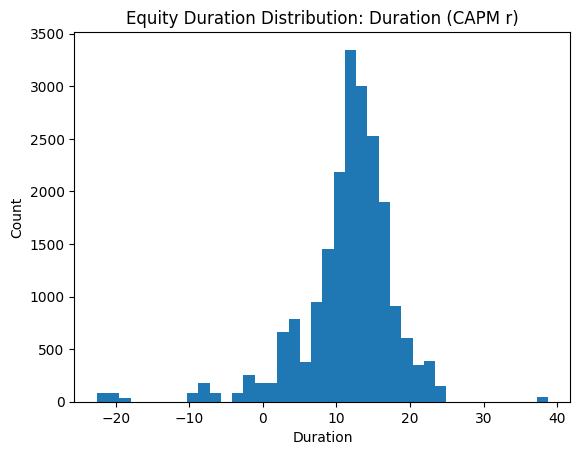

In [60]:
# --- 11. Diagnostics ---
print("Event dates (shocks):", df_shk["date"].nunique())
print("Event dates (panel day-0):", df_panel["date"].nunique())
print("Event dates (panel [0,+1]):", df_panel_01["date"].nunique())

# Missingness overview (day-0)
cols_check = ["AR", "ShockMP", "ShockInfo", "D_std"]
if "ln_mktcap" in df_panel.columns: cols_check.append("ln_mktcap")
if "Beta (5Y)" in df_panel.columns: cols_check.append("Beta (5Y)")
display(df_panel[cols_check].isna().mean().sort_values(ascending=False))

# Duration distribution
plt.figure()
plt.hist(df_panel[DUR_COL].dropna(), bins=40)
plt.title(f"Equity Duration Distribution: {DUR_COL}")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()


In [61]:
INT = DATA_DIR
INT.mkdir(exist_ok=True)

OUT = TABLE_DIR
OUT.mkdir(exist_ok=True)

# Save the final panel used
df_panel.to_parquet(INT / "panel_event_day0.parquet", index=False)

# Save regression tables as text
with open(OUT / "reg_m1_baseline.txt", "w") as f:
    f.write(m1.summary().as_text())

with open(OUT / "reg_m2_two_shock.txt", "w") as f:
    f.write(m2.summary().as_text())

print("Saved to:", OUT)

Saved to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables
